# From Level-2 Along-Track Altimetry to Level-4 Grids

## Deterministic Resampling and Optimal Interpolation with Sentinel-6A SSHA

**Course:** OCNG 489/689 Studying the Oceans from Space

### Learning goals

1. Understand the conceptual transition from **Level-2** along-track measurements to **Level-4** gridded maps.
2. Build a real case study from **Sentinel-6A** altimetry archived at **NASA PO.DAAC**.
3. Compare two mapping strategies:
   - deterministic binning / resampling
   - statistical optimal interpolation (OI; closely related to kriging)
4. Distinguish **interpolation**, **estimation**, **smoothing**, and **resolved scales**.
5. Connect this toy workflow to operational systems such as **DUACS** and to the **SWOT** era.

> **Earthdata login required:** the data-access cells use `earthaccess`, so you need a free NASA Earthdata Login.  
> This notebook tries the current reprocessed **G01** Sentinel-6A Level-2 LR NTC collection first and falls back to **F08** if needed.

## 1. Conceptual introduction: what changes from Level-2 to Level-4?

For satellite altimetry, a **Level-2** product contains geolocated geophysical variables sampled **along the satellite ground track**.  
A **Level-4** product reorganizes those irregular observations onto a **regular space/time grid**.

### Why gridding is needed

Altimetry does **not** observe the ocean on a full 2-D grid. A nadir altimeter only measures directly below the spacecraft, so the sampling is:

- dense **along-track**
- sparse **across-track**
- not synoptic unless you average over time

That means Level-2 data are excellent for precise local measurements, but oceanographers usually want a map:

- a regular latitude-longitude mesh
- a daily / weekly / cycle-averaged field
- a product that can be compared with models, climatologies, and other satellites

### Level-2 vs Level-4 in one table

| Product level | Geometry | Typical contents | Main advantage | Main limitation |
|---|---|---|---|---|
| **Level-2** | Along-track, irregular in space and time | SSHA, SSH-related corrections, lat/lon/time, wave height, wind speed | Closest to the measurement | Hard to interpret as a 2-D map |
| **Level-4** | Regular grid in space and often in time | Gridded SSHA/ADT/SSH and sometimes uncertainty | Easy to visualize and compare | Requires assumptions about smoothing, covariance, and error |

### Physical picture

Turning Level-2 into Level-4 is an **inverse problem**:

- we only know the field where the satellite passed
- we want a field everywhere on a grid
- we must decide how much to trust nearby points, distant points, and noisy observations

In this notebook we use **SSHA** (sea surface height anomaly) because anomalies are especially useful for studying mesoscale variability once the large mean surface has been removed.

### Case study design

We will build a small regional Level-4-style map in the **Gulf Stream / western North Atlantic** from roughly **one Sentinel-6 repeat cycle (~10 days)** of data.

This is a good use case because it highlights the central trade-off of nadir altimetry:

- longer averaging windows improve spatial coverage
- but longer windows also blur a time-evolving ocean

The mapping problem becomes even more interesting in the context of **SWOT**: nadir altimeters sample a 1-D track, while SWOT samples a 2-D swath and can resolve much shorter wavelengths. It is still a research question how to best **blend** two types of altimeter data. 

In [24]:
# If needed, install the small set of packages used in this notebook.
# This cell is safe to rerun.

import importlib.util
import subprocess
import sys

required = {
    "earthaccess": "earthaccess>=0.10",
    "pyresample": "pyresample>=1.28",
    "h5netcdf": "h5netcdf>=1.3",
    "xarray": "xarray>=2024.1",
    "numpy": "numpy>=1.26",
    "pandas": "pandas>=2.1",
    "scipy": "scipy>=1.11",
    "matplotlib": "matplotlib>=3.8",
}

missing = [spec for mod, spec in required.items() if importlib.util.find_spec(mod) is None]

if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("All required packages are already available.")

All required packages are already available.


In [25]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from scipy import stats
from scipy.interpolate import griddata
from scipy.spatial import cKDTree
from scipy.spatial.distance import cdist

from IPython.display import display

import earthaccess

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 180,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

CMAP_ANOM = "RdBu_r"
EARTH_RADIUS_KM = 6371.0

In [26]:
# -----------------------------
# Case-study configuration
# -----------------------------
CASE = {
    "name": "Gulf Stream (western North Atlantic)",
    "temporal": ("2024-03-01 00:00:00", "2024-03-11 00:00:00"),
    "bbox": (-76.0, 32.0, -56.0, 44.0),  # west, south, east, north
    "grid_res_deg": 0.25,
    "coast_buffer_km": 50.0,
}

# Current reprocessed release first; older release as fallback.
L2_SHORTNAME_CANDIDATES = [
    "JASON_CS_S6A_L2_ALT_LR_STD_OST_NTC_G01",
    "JASON_CS_S6A_L2_ALT_LR_STD_OST_NTC_F08",
]

# Optional official Level-3 comparison for later exercises.
L3_SHORTNAME_CANDIDATES = [
    "JASON_CS_S6A_L3_ALT_LR_OST_NTC_G01",
    "JASON_CS_S6A_L3_ALT_LR_OST_NTC_F08",
]

DATA_DIR = Path("data/sentinel6_l2_to_l3")
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Deterministic gridding parameters
GAUSS_SIGMA_KM = 50.0
GAUSS_RADIUS_KM = 150.0
GAUSS_MAX_NEIGHBORS = 64

# OI parameters
SUPEROB_DDEG = 0.15          # simple spatial thinning / superobbing
OI_DECORR_KM = 120.0         # Gaussian covariance length scale
OI_NOISE_STD_M = 0.03        # assumed measurement noise (3 cm)
OI_MIN_NEIGHBORS = 3
OI_MAX_NEIGHBORS = 20
OI_INFLUENCE_KM = 3.0 * OI_DECORR_KM

west, south, east, north = CASE["bbox"]
dlon = dlat = CASE["grid_res_deg"]

lon_centers = np.arange(west + dlon / 2, east, dlon)
lat_centers = np.arange(south + dlat / 2, north, dlat)
grid_lon2d, grid_lat2d = np.meshgrid(lon_centers, lat_centers)

print(CASE)
print(f"Output grid shape: {grid_lat2d.shape}")

{'name': 'Gulf Stream (western North Atlantic)', 'temporal': ('2024-03-01 00:00:00', '2024-03-11 00:00:00'), 'bbox': (-76.0, 32.0, -56.0, 44.0), 'grid_res_deg': 0.25, 'coast_buffer_km': 50.0}
Output grid shape: (48, 80)


## 2. Data access with `earthaccess`

We search **NASA PO.DAAC** for the Sentinel-6A along-track Level-2 low-resolution standard ocean topography product, authenticate with Earthdata, and download the small regional/time subset for this lesson.

We deliberately use the **1 Hz** variables in the `data_01` groups to keep the workflow lightweight and easy to understand.  
The standard Sentinel-6 product also includes higher-rate measurements, but 1 Hz is ideal for an introductory mapping notebook.

In [27]:
def search_case_granules(short_name_candidates, temporal, bbox):
    """
    Try each short name in order and return the first successful result list.
    """
    for short_name in short_name_candidates:
        try:
            results = earthaccess.search_data(
                short_name=short_name,
                temporal=temporal,
                bounding_box=bbox,
            )
        except TypeError:
            # Very old earthaccess versions may not accept bounding_box as a named kwarg.
            results = earthaccess.search_data(
                short_name=short_name,
                temporal=temporal,
            )

        if len(results) > 0:
            return short_name, results

    raise RuntimeError(
        "No granules found. Check the time window, bounding box, or short-name candidates."
    )


# Log in once per session. You can also set credentials through environment variables.
auth = earthaccess.login(persist=True)

chosen_l2_short_name, granules = search_case_granules(
    L2_SHORTNAME_CANDIDATES,
    CASE["temporal"],
    CASE["bbox"],
)

print(f"Selected Level-2 collection: {chosen_l2_short_name}")
print(f"Granules found: {len(granules)}")

Selected Level-2 collection: JASON_CS_S6A_L2_ALT_LR_STD_OST_NTC_G01
Granules found: 24


In [28]:
# Download granules only if we do not already have local copies.
# earthaccess.download returns local file paths in most recent versions.

local_files = sorted([
    p for p in DATA_DIR.rglob("*")
    if p.is_file() and (p.suffix in {".nc", ".nc4"} or ".nc" in p.name)
])

if not local_files:
    downloaded = earthaccess.download(granules, str(DATA_DIR))
    local_files = sorted([Path(p) for p in downloaded if str(p).endswith((".nc", ".nc4"))])

if not local_files:
    # Fallback: recursively scan the directory in case the version of earthaccess behaves differently.
    local_files = sorted([
        p for p in DATA_DIR.rglob("*")
        if p.is_file() and (p.suffix in {".nc", ".nc4"} or ".nc" in p.name)
    ])

if not local_files:
    raise FileNotFoundError(
        f"No NetCDF granules found under {DATA_DIR.resolve()} after download."
    )

print(f"Downloaded/available local granules: {len(local_files)}")
display(pd.DataFrame({"granule": [p.name for p in local_files[:10]]}))
if len(local_files) > 10:
    print("...")

Downloaded/available local granules: 24


,granule
0,S6A_P4_2__LR_STD__NT_121_243_20240229T235821_2...
1,S6A_P4_2__LR_STD__NT_121_252_20240301T082417_2...
2,S6A_P4_2__LR_STD__NT_122_013_20240301T222730_2...
3,S6A_P4_2__LR_STD__NT_122_024_20240302T084552_2...
4,S6A_P4_2__LR_STD__NT_122_039_20240302T224905_2...
5,S6A_P4_2__LR_STD__NT_122_050_20240303T090727_2...
6,S6A_P4_2__LR_STD__NT_122_065_20240303T231040_2...
7,S6A_P4_2__LR_STD__NT_122_074_20240304T073636_2...
8,S6A_P4_2__LR_STD__NT_122_076_20240304T092901_2...
9,S6A_P4_2__LR_STD__NT_122_091_20240304T233215_2...


...


## 3. Read the Level-2 granules and extract the variables we need

For this notebook we only need a handful of variables:

- `longitude`, `latitude`, `time` from `data_01`
- `ssha` from `data_01/ku`
- a few optional quality-control fields such as `surface_classification_flag`, `distance_to_coast`, and `range_ocean_qual`

A few practical notes:

1. We convert longitude to the interval $[-180^\circ, 180^\circ]$.
2. We keep only finite values inside the case-study bounding box.
3. We keep **open-ocean** samples when `surface_classification_flag == 0`.
4. We optionally keep only good range-quality values when a binary `range_ocean_qual` is available.
5. We remove points too close to the coast to avoid coastal contamination in this simple introductory example.

In [29]:
def open_group(filepath, group):
    return xr.open_dataset(
        filepath,
        group=group,
        engine="h5netcdf",
        decode_times=True,
        mask_and_scale=True,
    )


def to_minus180_180(lon):
    lon = np.asarray(lon, dtype=float)
    return ((lon + 180.0) % 360.0) - 180.0


def pick_existing(ds, candidates):
    for name in candidates:
        if name in ds.variables or name in ds.coords:
            return name
    raise KeyError(f"None of these variables were found: {candidates}")


def extract_l2_records(filepath):
    """
    Extract the minimum set of Level-2 variables needed for the notebook.

    Product-structure assumptions:
      - data_01 contains time, lat, lon, and several QC fields
      - data_01/ku contains the Ku-band SSHA variable
    """
    ds01 = open_group(filepath, "data_01")
    ku = open_group(filepath, "data_01/ku")

    time_name = pick_existing(ds01, ["time"])
    lon_name = pick_existing(ds01, ["longitude"])
    lat_name = pick_existing(ds01, ["latitude"])
    ssha_name = pick_existing(ku, ["ssha"])

    frame = pd.DataFrame({
        "time": pd.to_datetime(ds01[time_name].values),
        "lon": to_minus180_180(ds01[lon_name].values),
        "lat": np.asarray(ds01[lat_name].values, dtype=float),
        "ssha_m": np.asarray(ku[ssha_name].values, dtype=float),
        "granule": Path(filepath).name,
    })

    # Optional variables: useful for filtering or extensions.
    for name in [
        "surface_classification_flag",
        "distance_to_coast",
        "mean_dynamic_topography",
        "mean_dynamic_topography_qual",
    ]:
        if name in ds01:
            frame[name] = np.asarray(ds01[name].values)

    for name in [
        "range_ocean_qual",
        "swh_ocean_qual",
        "sig0_ocean_qual",
    ]:
        if name in ku:
            frame[name] = np.asarray(ku[name].values)

    ds01.close()
    ku.close()
    return frame


def load_case_study(files, bbox):
    west, south, east, north = bbox
    frames = [extract_l2_records(fp) for fp in files]
    obs = pd.concat(frames, ignore_index=True)

    mask = (
        np.isfinite(obs["lon"]) &
        np.isfinite(obs["lat"]) &
        np.isfinite(obs["ssha_m"]) &
        obs["lon"].between(west, east) &
        obs["lat"].between(south, north) &
        (np.abs(obs["ssha_m"]) < 3.0)
    )

    if "surface_classification_flag" in obs:
        sf = pd.to_numeric(obs["surface_classification_flag"], errors="coerce")
        # Sentinel-6 variable catalog: 0 = open ocean
        mask &= sf.eq(0)

    if "distance_to_coast" in obs:
        dist_coast = pd.to_numeric(obs["distance_to_coast"], errors="coerce")
        mask &= dist_coast > CASE["coast_buffer_km"] * 1000.0

    if "range_ocean_qual" in obs:
        rq = pd.to_numeric(obs["range_ocean_qual"], errors="coerce")
        uniq = sorted(rq.dropna().unique().tolist())
        if len(uniq) > 0 and set(uniq).issubset({0, 1}) and (rq.eq(0).any()):
            mask &= rq.eq(0)

    obs = obs.loc[mask].sort_values("time").reset_index(drop=True)
    return obs


obs = load_case_study(local_files, CASE["bbox"])

summary = pd.DataFrame({
    "n_obs": [len(obs)],
    "n_granules_used": [obs["granule"].nunique()],
    "time_start": [obs["time"].min()],
    "time_end": [obs["time"].max()],
    "mean_ssha_m": [obs["ssha_m"].mean()],
    "std_ssha_m": [obs["ssha_m"].std()],
})

display(summary)
display(obs.head())

,n_obs,n_granules_used,time_start,time_end,mean_ssha_m,std_ssha_m
0,3336,19,2024-03-01 00:37:57,2024-03-10 22:40:09,-0.005581,0.177304


,time,lon,lat,ssha_m,granule,surface_classification_flag,distance_to_coast,mean_dynamic_topography,mean_dynamic_topography_qual,range_ocean_qual,swh_ocean_qual,sig0_ocean_qual
0,2024-03-01 00:37:57,-75.986800,33.318254,0.0669,S6A_P4_2__LR_STD__NT_121_243_20240229T235821_2...,0.0,149000.0,0.5965,0.0,0.0,0.0,0.0
1,2024-03-01 00:37:58,-75.960032,33.365019,0.0262,S6A_P4_2__LR_STD__NT_121_243_20240229T235821_2...,0.0,145000.0,0.5933,0.0,0.0,0.0,0.0
2,2024-03-01 00:37:59,-75.933230,33.411775,0.0572,S6A_P4_2__LR_STD__NT_121_243_20240229T235821_2...,0.0,141200.0,0.5912,0.0,0.0,0.0,0.0
3,2024-03-01 00:38:00,-75.906396,33.458524,0.0510,S6A_P4_2__LR_STD__NT_121_243_20240229T235821_2...,0.0,137400.0,0.5868,0.0,0.0,0.0,0.0
4,2024-03-01 00:38:01,-75.879528,33.505264,0.0982,S6A_P4_2__LR_STD__NT_121_243_20240229T235821_2...,0.0,133900.0,0.5789,0.0,0.0,0.0,0.0


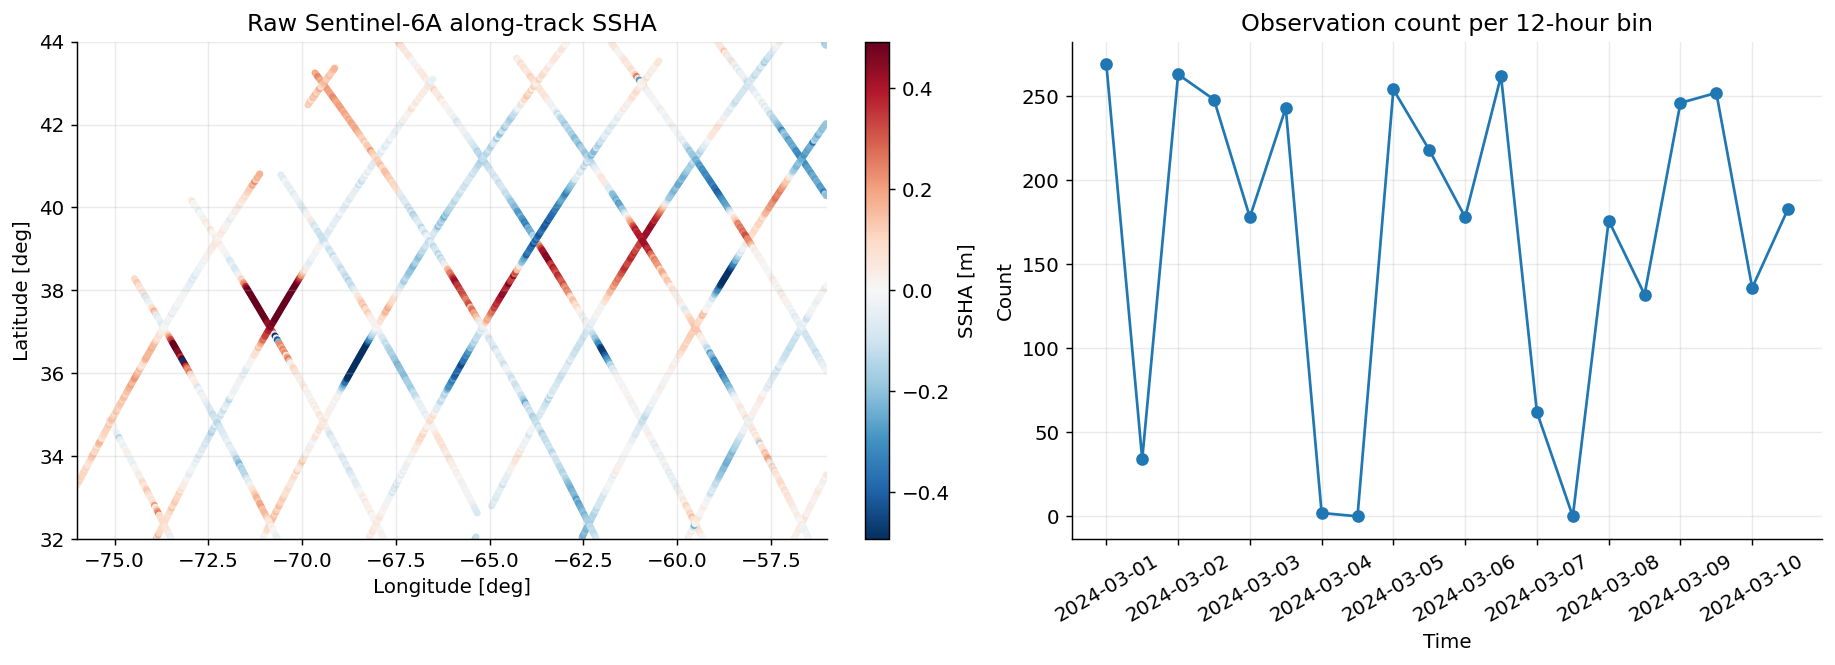

In [30]:
anom_limit = float(np.nanpercentile(np.abs(obs["ssha_m"]), 98))
anom_limit = float(np.clip(anom_limit, 0.15, 0.80))

counts_12h = obs.set_index("time").resample("12H").size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sc = axes[0].scatter(
    obs["lon"], obs["lat"],
    c=obs["ssha_m"],
    s=8,
    cmap=CMAP_ANOM,
    vmin=-anom_limit,
    vmax=anom_limit,
)
axes[0].set_title("Raw Sentinel-6A along-track SSHA")
axes[0].set_xlabel("Longitude [deg]")
axes[0].set_ylabel("Latitude [deg]")
axes[0].set_xlim(west, east)
axes[0].set_ylim(south, north)
fig.colorbar(sc, ax=axes[0], label="SSHA [m]")

axes[1].plot(counts_12h.index, counts_12h.values, marker="o", lw=1.5)
axes[1].set_title("Observation count per 12-hour bin")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=30)

plt.show()

### What do we see?

The left panel shows the key Level-2 fact: **measurements only exist along the ground tracks**.  
Between tracks there are gaps, so a 2-D map is not observed directly.

The right panel reminds us that our Level-4 map will be only **quasi-synoptic**, because we are combining data from a roughly 10-day window.  
That is a central approximation of nadir-altimeter mapping.

## 4. Method 1 — deterministic gridding / resampling

We start with simpler, non-statistical methods.

### 4.1 Cell-average binning

A very basic Level-4 estimate is the average of all observations that fall inside a grid cell:

$$
\hat z_{ij} = \frac{1}{N_{ij}} \sum_{k \in 	\text{cell}_{ij}} z_k
$$

where $N_{ij}$ is the number of observations in grid cell $(i,j)$.

This is easy to understand and fast to compute, but it leaves holes where no observations fall into the cell.

### 4.2 Distance-weighted resampling

Instead of averaging only points inside one grid cell, we can map nearby observations to a grid point $\mathbf{x}_g$ with a kernel:

$$
\hat z(\mathbf{x}_g) =
\frac{\sum_k w_k z_k}{\sum_k w_k},
\qquad
w_k = \exp\!\left(-
\frac{d_k^2}{2\sigma^2}
\right)
$$

where $d_k$ is the distance from observation $k$) to the grid point.

- **Nearest neighbor** is the special case where only the closest point is used.
- **Gaussian weighting** uses several nearby points and smooths the field.

These are still deterministic methods:
they do **not** provide a statistically consistent mapping error estimate.

In [31]:
def lonlat_to_xy_km(lon, lat, lon0=None, lat0=None):
    """
    Local tangent-plane approximation in kilometers.
    Good enough for a regional teaching example.
    """
    lon = np.asarray(lon, dtype=float)
    lat = np.asarray(lat, dtype=float)

    if lon0 is None:
        lon0 = float(np.nanmean(lon))
    if lat0 is None:
        lat0 = float(np.nanmean(lat))

    x = EARTH_RADIUS_KM * np.deg2rad(lon - lon0) * np.cos(np.deg2rad(lat0))
    y = EARTH_RADIUS_KM * np.deg2rad(lat - lat0)
    return x, y, lon0, lat0


def bin_average_2d(obs_df, lon_centers, lat_centers, dlon, dlat):
    lon_edges = np.r_[lon_centers - dlon / 2, lon_centers[-1] + dlon / 2]
    lat_edges = np.r_[lat_centers - dlat / 2, lat_centers[-1] + dlat / 2]

    ssum, _, _, _ = stats.binned_statistic_2d(
        obs_df["lon"], obs_df["lat"], obs_df["ssha_m"],
        statistic="sum",
        bins=[lon_edges, lat_edges],
    )
    count, _, _, _ = stats.binned_statistic_2d(
        obs_df["lon"], obs_df["lat"], obs_df["ssha_m"],
        statistic="count",
        bins=[lon_edges, lat_edges],
    )

    mean = ssum / count

    coords = {"lat": lat_centers, "lon": lon_centers}
    mean_da = xr.DataArray(mean.T, coords=coords, dims=("lat", "lon"), name="bin_mean")
    count_da = xr.DataArray(count.T, coords=coords, dims=("lat", "lon"), name="bin_count")
    return mean_da, count_da


def gaussian_resample_fallback(
    obs_df,
    lon_centers,
    lat_centers,
    sigma_km=50.0,
    radius_km=150.0,
    max_neighbors=64,
):
    """
    Local Gaussian kernel smoother used only if pyresample is unavailable.
    Returns (mapped_field, local_spread, n_neighbors).
    """
    x_obs, y_obs, lon0, lat0 = lonlat_to_xy_km(obs_df["lon"].values, obs_df["lat"].values)
    vals = obs_df["ssha_m"].values

    glon2d, glat2d = np.meshgrid(lon_centers, lat_centers)
    xg, yg, _, _ = lonlat_to_xy_km(glon2d, glat2d, lon0=lon0, lat0=lat0)

    tree = cKDTree(np.c_[x_obs, y_obs])

    result = np.full(xg.shape, np.nan)
    spread = np.full(xg.shape, np.nan)
    count = np.zeros(xg.shape, dtype=float)

    for i, pt in enumerate(np.c_[xg.ravel(), yg.ravel()]):
        idx = tree.query_ball_point(pt, r=radius_km)
        if len(idx) == 0:
            continue

        idx = np.asarray(idx, dtype=int)
        d = np.hypot(x_obs[idx] - pt[0], y_obs[idx] - pt[1])

        if idx.size > max_neighbors:
            take = np.argsort(d)[:max_neighbors]
            idx = idx[take]
            d = d[take]

        w = np.exp(-0.5 * (d / sigma_km) ** 2)
        if np.allclose(w.sum(), 0.0):
            continue

        val = np.average(vals[idx], weights=w)
        var = np.average((vals[idx] - val) ** 2, weights=w)

        result.ravel()[i] = val
        spread.ravel()[i] = np.sqrt(var)
        count.ravel()[i] = idx.size

    return result, spread, count


def plot_lonlat_field(ax, da, title, cmap=CMAP_ANOM, vmin=None, vmax=None):
    im = ax.pcolormesh(
        da["lon"].values,
        da["lat"].values,
        da.values,
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(title)
    ax.set_xlabel("Longitude [deg]")
    ax.set_ylabel("Latitude [deg]")
    ax.set_xlim(west, east)
    ax.set_ylim(south, north)
    return im

In [32]:
# Cell-average binning
bin_grid, bin_count = bin_average_2d(obs, lon_centers, lat_centers, dlon, dlat)

# Nearest-neighbor mapping for comparison
nearest_grid = griddata(
    np.c_[obs["lon"].values, obs["lat"].values],
    obs["ssha_m"].values,
    (grid_lon2d, grid_lat2d),
    method="nearest",
)
nearest_grid = xr.DataArray(
    nearest_grid,
    coords={"lat": lat_centers, "lon": lon_centers},
    dims=("lat", "lon"),
    name="nearest",
)

# Gaussian kernel resampling (pyresample if available; otherwise a custom fallback)
try:
    from pyresample import geometry, kd_tree

    swath = geometry.SwathDefinition(
        lons=obs["lon"].values,
        lats=obs["lat"].values,
    )
    target = geometry.SwathDefinition(
        lons=grid_lon2d,
        lats=grid_lat2d,
    )

    gauss_np, gauss_spread_np, gauss_count_np = kd_tree.resample_gauss(
        swath,
        obs["ssha_m"].values,
        target,
        radius_of_influence=GAUSS_RADIUS_KM * 1000.0,
        sigmas=GAUSS_SIGMA_KM * 1000.0,
        neighbours=GAUSS_MAX_NEIGHBORS,
        fill_value=np.nan,
        with_uncert=True,
    )
    print("Used pyresample.resample_gauss")
except Exception as e:
    print("pyresample unavailable or failed; using local Gaussian fallback instead.")
    print(f"Reason: {e}")
    gauss_np, gauss_spread_np, gauss_count_np = gaussian_resample_fallback(
        obs,
        lon_centers,
        lat_centers,
        sigma_km=GAUSS_SIGMA_KM,
        radius_km=GAUSS_RADIUS_KM,
        max_neighbors=GAUSS_MAX_NEIGHBORS,
    )

gauss_grid = xr.DataArray(
    gauss_np,
    coords={"lat": lat_centers, "lon": lon_centers},
    dims=("lat", "lon"),
    name="gaussian",
)
gauss_spread = xr.DataArray(
    gauss_spread_np,
    coords={"lat": lat_centers, "lon": lon_centers},
    dims=("lat", "lon"),
    name="gaussian_spread",
)
gauss_count = xr.DataArray(
    gauss_count_np,
    coords={"lat": lat_centers, "lon": lon_centers},
    dims=("lat", "lon"),
    name="gaussian_count",
)

Used pyresample.resample_gauss


/srv/conda/envs/notebook/lib/python3.12/site-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 64 neighbours within 150000.0 m for some data points
  get_neighbour_info(source_geo_def,


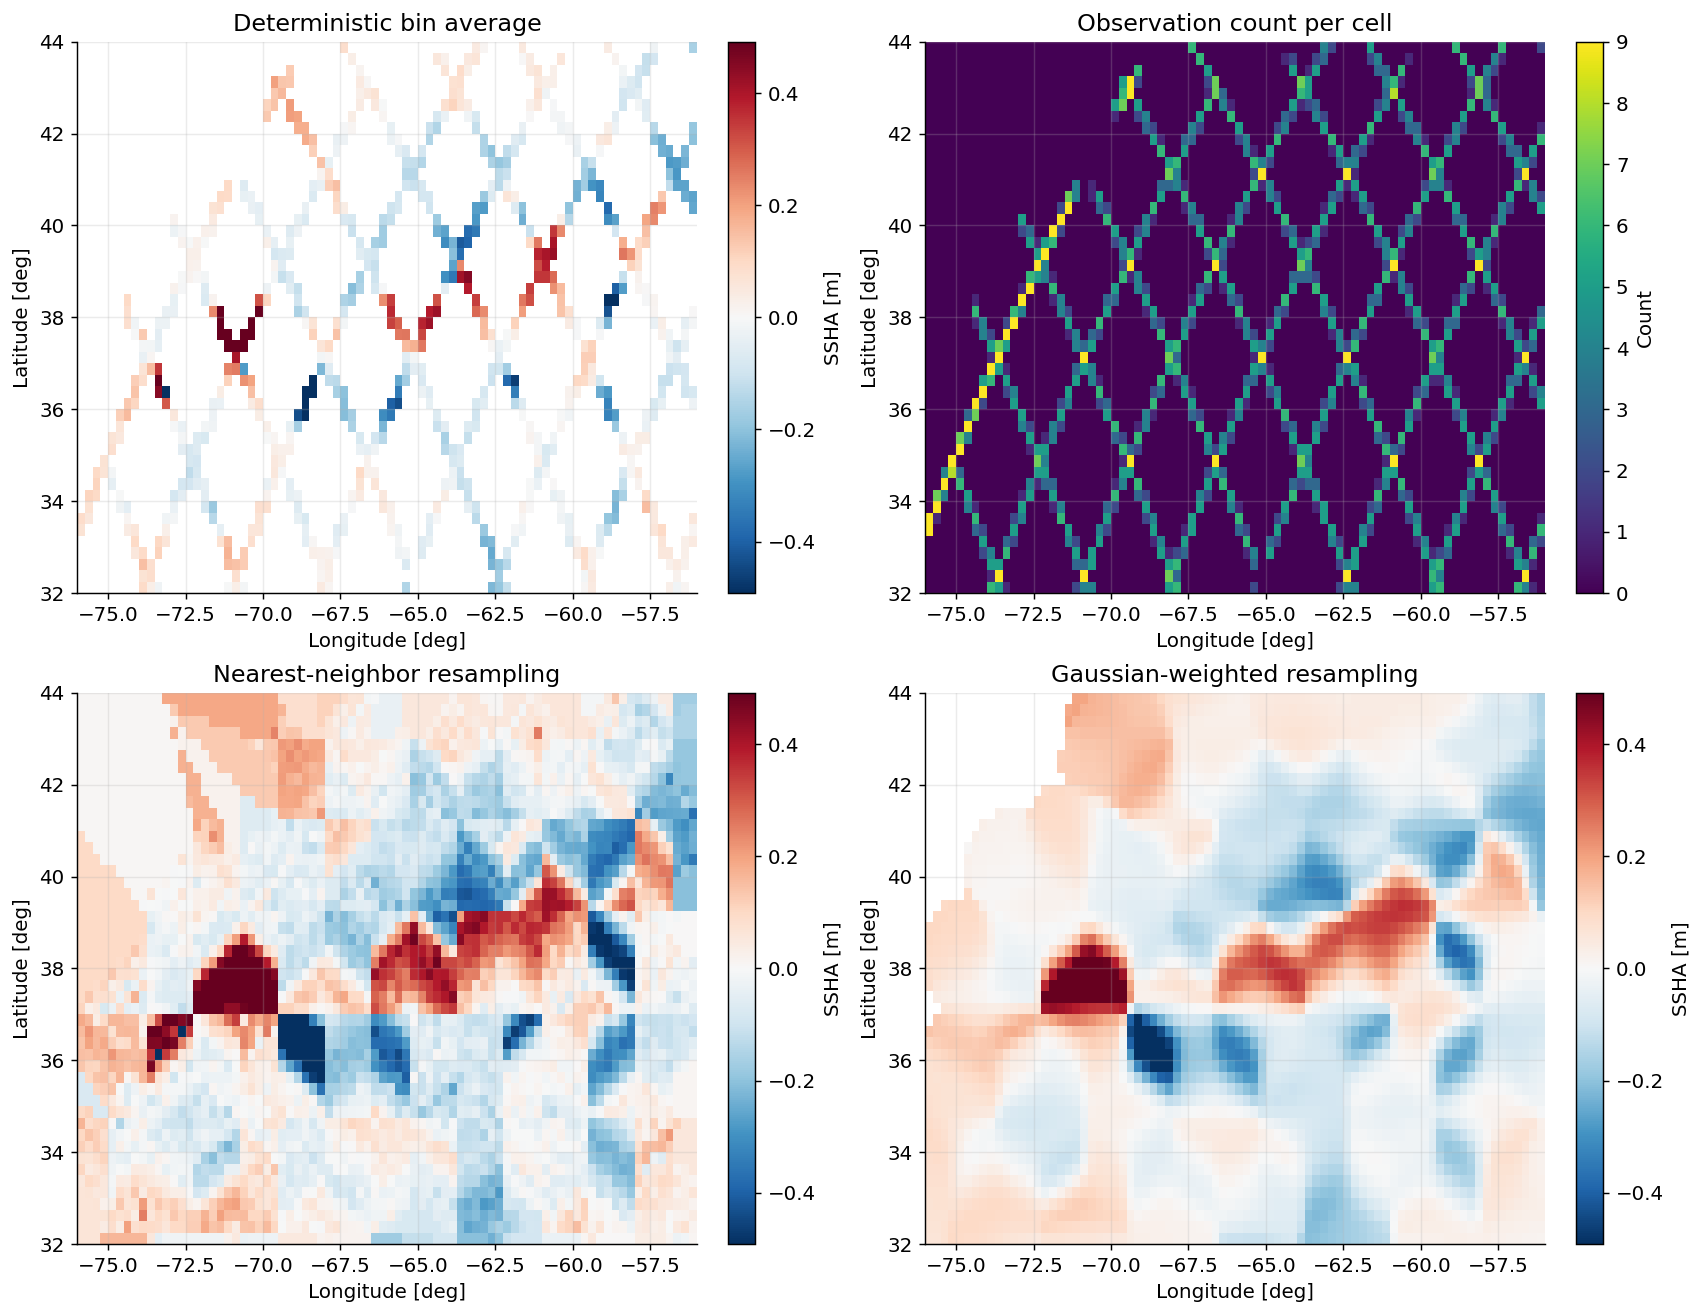

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)

im = plot_lonlat_field(
    axes[0, 0], bin_grid,
    "Deterministic bin average",
    vmin=-anom_limit, vmax=anom_limit,
)
fig.colorbar(im, ax=axes[0, 0], label="SSHA [m]")

im = plot_lonlat_field(
    axes[0, 1], bin_count,
    "Observation count per cell",
    cmap="viridis",
    vmin=0, vmax=float(np.nanpercentile(bin_count.values, 99)),
)
fig.colorbar(im, ax=axes[0, 1], label="Count")

im = plot_lonlat_field(
    axes[1, 0], nearest_grid,
    "Nearest-neighbor resampling",
    vmin=-anom_limit, vmax=anom_limit,
)
fig.colorbar(im, ax=axes[1, 0], label="SSHA [m]")

im = plot_lonlat_field(
    axes[1, 1], gauss_grid,
    "Gaussian-weighted resampling",
    vmin=-anom_limit, vmax=anom_limit,
)
fig.colorbar(im, ax=axes[1, 1], label="SSHA [m]")

plt.show()

### Discussion: deterministic gridding

**Advantages**
- easy to understand
- computationally cheap
- useful as a first Level-4 product

**Limitations**
- no formal uncertainty estimate
- results depend strongly on grid resolution and radius of influence
- nearest neighbor can look blocky
- Gaussian resampling smooths, but the smoothing scale is chosen by us rather than inferred from a covariance model

This leads naturally to a more statistical question:

> *If I know something about the covariance of mesoscale variability and about observation noise, can I produce a better estimate and a mapping error?*

## 5. Method 2 — optimal interpolation (OI) / kriging

Optimal interpolation is a classic oceanographic mapping method, also known as **objective mapping**.  
In geostatistical language, the version used here is closely related to **simple kriging**.

The key idea is that the mapped value at a grid point is not just a weighted average based on distance alone.  
Instead, the weights come from an explicit **covariance model** plus an **observation error model**.

### 5.1 The core OI equation

$$
\hat{x} = C_{xo}\,(C_{oo}+R)^{-1}\,y
$$

where

- $\hat{x}$ is the estimated field at the target grid point  
- $y$ is the vector of observations  
- $C_{oo}$ is the observation–observation covariance matrix  
- $C_{xo}$ is the covariance between the target point and the observations  
- $R$ is the observation-noise covariance matrix  

---

### 5.2 Our covariance model

### 5.2.1 What does “covariance” mean physically?

The covariance function encodes how similar two points in the ocean are expected to be as a function of their separation distance.

Formally, the covariance between two locations $x_i$ and $x_j$ is:

$$
C(x_i, x_j) = \mathbb{E}\big[(z_i - \bar{z})(z_j - \bar{z})\big]
$$

In practice, we assume **stationarity** and **isotropy**, so covariance depends only on distance:

$$
C(x_i, x_j) = C(d_{ij})
$$

---

### Intuition

- **Nearby points → high covariance**  
  → ocean signals (e.g., SSH) are spatially coherent  

- **Far-apart points → low covariance**  
  → signals become independent  

- The covariance function defines a **spatial correlation length scale**

---

### Role of the decorrelation scale $L$

In our Gaussian model:

$$
C(d) = \sigma_s^2 \exp\!\left[-\left(\frac{d}{L}\right)^2\right]
$$

- $L$ controls how fast correlation decays with distance  
- Physically, $L$ represents the **typical size of coherent structures**

For sea surface height:

- $L \sim 50$–150 km → mesoscale eddies  
- Smaller $L$ → sharper features but noisier map  
- Larger $L$ → smoother map but loss of small-scale variability  

---

### Why covariance matters for OI

Covariance determines the interpolation weights:

- Observations with **higher covariance to the target point** get more weight  
- Observations with **lower covariance** contribute less  

This leads to a key distinction:

- **Deterministic gridding** → weights based only on distance  
- **Optimal interpolation** → weights based on *statistical structure of the ocean field*

---

### Connection to ocean dynamics

The assumed covariance model is not arbitrary:

- It reflects underlying dynamics (e.g., geostrophic turbulence, Rossby radius)
- In operational systems (e.g., DUACS), covariance parameters are tuned using:
  - historical variability
  - spectra of SSH
  - regional dynamics

Thus, OI is not just interpolation — it is a **statistical model of ocean variability**.

For this notebook we use an isotropic Gaussian covariance:

$$
C(d) = \sigma_s^2 \exp\!\left[-\left(\frac{d}{L}\right)^2\right]
$$

where

- $d$ is separation distance  
- $L$ is the decorrelation length scale  
- $\sigma_s^2$ is the signal variance  

We assume independent observation noise:

$$
R = \sigma_\epsilon^2 I
$$

---

### 5.3 Posterior uncertainty and analysis error variance


A major strength of OI is that it also gives a local analysis error variance:

$$
\sigma_a^2(x) = C_{xx} - C_{xo}(C_{oo}+R)^{-1}C_{ox}
$$

So unlike deterministic binning, OI tells us where the map is better constrained and where it is uncertain.

A major strength of OI is that it does not only provide an interpolated value.  
It also provides an estimate of the **remaining uncertainty** after the observations are used.

Let the true value at target location $x$ be $z(x)$, and let the OI estimate be $\hat{z}(x)$.  
Define the **analysis error** as

$$
e_a(x) = z(x) - \hat{z}(x)
$$

The quantity we want is the **analysis error variance**:

$$
\sigma_a^2(x) = \mathbb{E}\big[e_a(x)^2\big]
$$

This tells us how uncertain the mapped value remains at that location.

---

#### Step 1: Write the OI estimate

In OI, the estimate is a linear combination of the observations:

$$
\hat{z}(x) = w^\top y
$$

where $w$ is the vector of OI weights.  
For the minimum-variance linear estimate,

$$
w^\top = C_{xo}(C_{oo}+R)^{-1}
$$

so that

$$
\hat{z}(x) = C_{xo}(C_{oo}+R)^{-1} y
$$

---

#### Step 2: Define the error

Substitute the estimate into the error definition:

$$
e_a(x) = z(x) - w^\top y
$$

The variance of this error is

$$
\sigma_a^2(x) = \mathbb{E}\left[(z(x)-w^\top y)^2\right]
$$

Expand the square:

$$
\sigma_a^2(x)
=
\mathbb{E}[z(x)^2]
- 2\,w^\top \mathbb{E}[y\,z(x)]
+ w^\top \mathbb{E}[y y^\top] w
$$

Now identify each term:

- $\mathbb{E}[z(x)^2] = C_{xx}$, the prior variance at the target point
- $\mathbb{E}[y\,z(x)] = C_{ox}$
- $\mathbb{E}[y y^\top] = C_{oo}+R$

Therefore,

$$
\sigma_a^2(x)
=
C_{xx}
- 2\,w^\top C_{ox}
+ w^\top (C_{oo}+R) w
$$

---

#### Step 3: Substitute the optimal weights

Using

$$
w^\top = C_{xo}(C_{oo}+R)^{-1}
$$

the last two terms simplify, giving

$$
\sigma_a^2(x)
=
C_{xx} - C_{xo}(C_{oo}+R)^{-1}C_{ox}
$$

This is the standard OI posterior variance formula.

---

#### Interpretation of each term

$$
\sigma_a^2(x) = C_{xx} - C_{xo}(C_{oo}+R)^{-1}C_{ox}
$$

- $C_{xx}$ is the **prior variance**: how uncertain we would be without using any observations
- $C_{xo}(C_{oo}+R)^{-1}C_{ox}$ is the **variance reduction** provided by the observations
- The more informative the nearby observations are, the larger this reduction becomes
- Therefore, $\sigma_a^2(x)$ gets smaller where the observations constrain the field well

---

#### Limiting cases

##### 1. No useful nearby observations

If the target point is far from all observations, then $C_{xo} \approx 0$, so

$$
\sigma_a^2(x) \approx C_{xx}
$$

That means the analysis is almost as uncertain as the prior guess.

##### 2. Dense, accurate nearby observations

If observations are close to the target and noise is small, then the covariance term is large, and

$$
\sigma_a^2(x) \ll C_{xx}
$$

So the mapped field is well constrained.

##### 3. Large observation noise

If $R$ is large, then $(C_{oo}+R)^{-1}$ becomes smaller in effect, so the variance reduction weakens.  
Even if observations are nearby, noisy data do not constrain the map strongly.

---

#### Why this matters physically

This is one of the most important differences between **deterministic gridding** and **OI**:

- Deterministic gridding gives a map
- OI gives both:
  1. a map
  2. an estimate of how trustworthy that map is

So unlike deterministic binning, OI tells us where the map is better constrained and where it is uncertain.

In oceanography, this is essential because sampling is often highly uneven:

- uncertainty is lower near tracks and track crossovers
- uncertainty is higher in data gaps
- uncertainty also depends on the assumed correlation scale and measurement noise

Thus, the OI error variance is a compact way to summarize the local resolving power of the observing system.

### 5.4 Demo — OI handles clustered observations better than naive averaging

A common sampling problem in oceanography is **oversampling in one small area**.

For example:

- several observations may be taken very close together
- only a few observations may exist elsewhere
- a simple averaging or distance-based interpolation can let the dense cluster dominate the estimate

Optimal interpolation handles this more intelligently.

Why?

Because OI does not only ask:

- *How close is each observation to the target?*

It also asks:

- *How redundant are the observations with each other?*

If many observations are packed into a small area, they have large mutual covariance, so they do **not** provide as much independent information as the same number of widely separated observations.

In matrix form, this effect enters through

$$
\hat{x} = C_{xo}(C_{oo}+R)^{-1}y
$$

where:

- $C_{xo}$ measures target-to-observation covariance
- $C_{oo}$ measures observation-to-observation covariance

So a dense cluster is recognized as partly redundant, and its combined influence is reduced.

This is one reason OI is often more robust than deterministic gridding when sampling is highly uneven.

/tmp/ipykernel_2024/1819634770.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sigma_a = np.sqrt(float(sigma_a2))


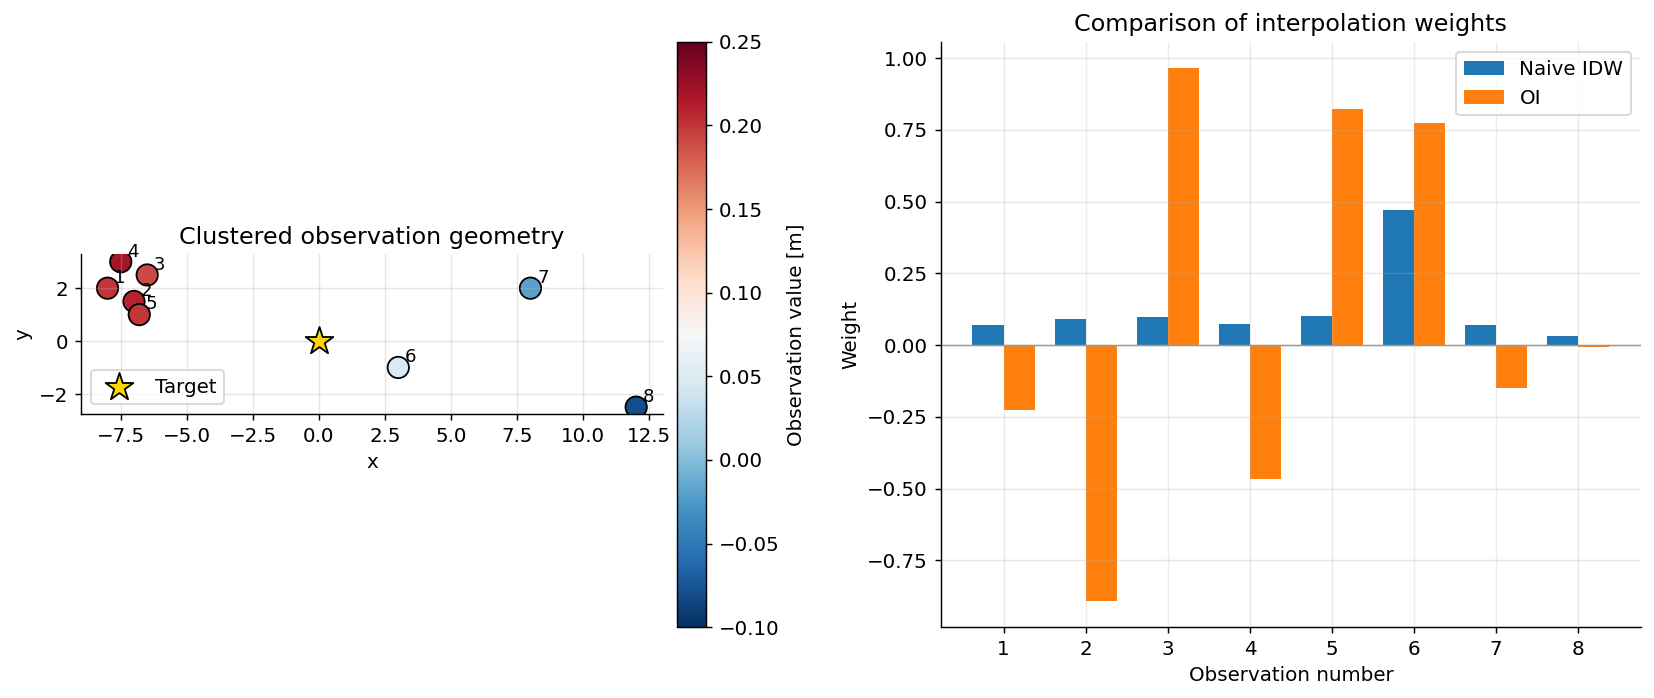

Naive IDW estimate at target: 0.107 m
OI estimate at target:        0.055 m
OI posterior std. dev.:       0.108 m

Total weight on dense cluster:
  IDW: 0.429
  OI : 0.203

Total weight on separated observations:
  IDW: 0.571
  OI : 0.618


In [34]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Synthetic example:
# many observations packed in one small cluster,
# plus a few more isolated observations elsewhere
# ---------------------------------------------------

obs_xy = np.array([
    [-8.0,  2.0],
    [-7.0,  1.5],
    [-6.5,  2.5],
    [-7.5,  3.0],
    [-6.8,  1.0],   # 5-point dense cluster on left
    [ 3.0, -1.0],
    [ 8.0,  2.0],
    [12.0, -2.5],   # 3 more separated observations
])

obs_val = np.array([
    0.20, 0.21, 0.19, 0.22, 0.20,   # clustered values
    0.05, -0.02, -0.08              # broader-scale variation elsewhere
])

target_xy = np.array([0.0, 0.0])

# ---------------------------------------------------
# Covariance model
# ---------------------------------------------------
sigma_s2 = 0.04      # signal variance [m^2]
L = 6.0              # decorrelation length scale [same units as x-y]
sigma_eps2 = 0.01**2 # observation noise variance [m^2]

def pairwise_distance(a, b):
    """Euclidean distance matrix between arrays of shape (N,2) and (M,2)."""
    da = a[:, None, :] - b[None, :, :]
    return np.sqrt(np.sum(da**2, axis=2))

def gaussian_cov(d, sigma_s2, L):
    return sigma_s2 * np.exp(-(d / L)**2)

# ---------------------------------------------------
# OI weights
# ---------------------------------------------------
d_oo = pairwise_distance(obs_xy, obs_xy)
d_xo = pairwise_distance(target_xy[None, :], obs_xy)

C_oo = gaussian_cov(d_oo, sigma_s2, L)
C_xo = gaussian_cov(d_xo, sigma_s2, L)  # shape (1, N)
R = sigma_eps2 * np.eye(len(obs_xy))

w_oi = (C_xo @ np.linalg.inv(C_oo + R)).ravel()
xhat_oi = np.sum(w_oi * obs_val)

# Posterior variance
C_xx = sigma_s2
sigma_a2 = C_xx - C_xo @ np.linalg.inv(C_oo + R) @ C_xo.T
sigma_a = np.sqrt(float(sigma_a2))

# ---------------------------------------------------
# Naive inverse-distance weighting (IDW) for comparison
# ---------------------------------------------------
d = np.sqrt(np.sum((obs_xy - target_xy[None, :])**2, axis=1))
d = np.maximum(d, 1e-6)
w_idw = 1.0 / d**2
w_idw = w_idw / w_idw.sum()
xhat_idw = np.sum(w_idw * obs_val)

# ---------------------------------------------------
# Plot geometry
# ---------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
sc = ax.scatter(
    obs_xy[:, 0], obs_xy[:, 1],
    c=obs_val, s=140, cmap="RdBu_r", vmin=-0.1, vmax=0.25,
    edgecolor="k"
)
ax.scatter(
    target_xy[0], target_xy[1],
    marker="*", s=260, c="gold", edgecolor="k", label="Target", zorder=5
)

for i, (xy, val) in enumerate(zip(obs_xy, obs_val), start=1):
    ax.text(xy[0] + 0.25, xy[1] + 0.2, f"{i}", fontsize=10)

ax.set_title("Clustered observation geometry")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.3)
ax.legend()

cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("Observation value [m]")

# ---------------------------------------------------
# Plot weights comparison
# ---------------------------------------------------
ax = axes[1]
idx = np.arange(len(obs_xy))
width = 0.38

ax.bar(idx - width/2, w_idw, width=width, label="Naive IDW")
ax.bar(idx + width/2, w_oi,  width=width, label="OI")

ax.set_xticks(idx)
ax.set_xticklabels([str(i) for i in range(1, len(obs_xy)+1)])
ax.set_xlabel("Observation number")
ax.set_ylabel("Weight")
ax.set_title("Comparison of interpolation weights")
ax.axhline(0, linewidth=0.8, color="0.6")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------
# Print numerical summary
# ---------------------------------------------------
cluster_idx = np.arange(5)      # first 5 are clustered
spread_idx = np.arange(5, 8)    # last 3 are more separated

print("Naive IDW estimate at target: {:.3f} m".format(xhat_idw))
print("OI estimate at target:        {:.3f} m".format(xhat_oi))
print("OI posterior std. dev.:       {:.3f} m".format(sigma_a))
print()

print("Total weight on dense cluster:")
print("  IDW: {:.3f}".format(w_idw[cluster_idx].sum()))
print("  OI : {:.3f}".format(w_oi[cluster_idx].sum()))
print()

print("Total weight on separated observations:")
print("  IDW: {:.3f}".format(w_idw[spread_idx].sum()))
print("  OI : {:.3f}".format(w_oi[spread_idx].sum()))

### Interpretation

In the plot above, observations 1–5 are tightly clustered, so they are highly redundant.

A naive distance-based method tends to give this cluster a large total weight simply because it contains many nearby points.

OI behaves differently:

- each clustered observation is not treated as fully independent
- their mutual covariance appears in $C_{oo}$
- the inversion of $(C_{oo}+R)$ reduces the combined influence of redundant samples

As a result, OI usually assigns:

- **smaller total weight to the dense cluster**
- **more balanced influence to the spatially separated observations**

This does **not** mean OI magically removes all sampling bias.  
Its performance still depends on the covariance model and noise assumptions.

But compared with deterministic methods, OI is much better able to recognize that
“many measurements in one tiny area” do not necessarily mean “many independent pieces of information.”

### 5.5 Historical note — from gold mining to ocean mapping

The method we call **optimal interpolation (OI)** in oceanography originates from **kriging**, a technique developed in mining geology named after South African mining engineer Danie Krige.

- Named after South African mining engineer **Danie Krige**
- Formalized by geostatistician **Georges Matheron** in the 1950s–60s
- Originally used to estimate **gold concentrations** from sparse drill samples

---

### The original problem

In gold mining:

- Measurements come from **drill cores** at sparse, irregular locations  
- The goal is to estimate:
  - where high-value ore is located  
  - and how uncertain that estimate is  

This is mathematically identical to what we do in oceanography:

| Geology (mining)        | Oceanography (altimetry) |
|------------------------|--------------------------|
| Gold concentration     | Sea surface height (SSH) |
| Drill samples          | Satellite tracks         |
| Ore body structure     | Ocean variability        |
| Resource estimate      | Gridded field (L3)       |
| Estimation uncertainty | Mapping error variance   |

---

### Why kriging/OI is powerful

Kriging introduced two key ideas:

1. **Use spatial covariance to determine weights**  
   → not just distance, but how the field varies statistically  

2. **Quantify uncertainty explicitly**  
   → where estimates are reliable vs uncertain  

These are exactly the principles behind OI in satellite oceanography.

---

### Take-home message

> The same mathematics used to locate hidden gold deposits is now used to map the ocean surface from space.

This highlights a broader idea:

- OI/kriging is a **general framework for estimating spatial fields from sparse observations**
- Its applications span:
  - geology (mineral exploration)
  - meteorology (data assimilation)
  - oceanography (altimetry mapping)

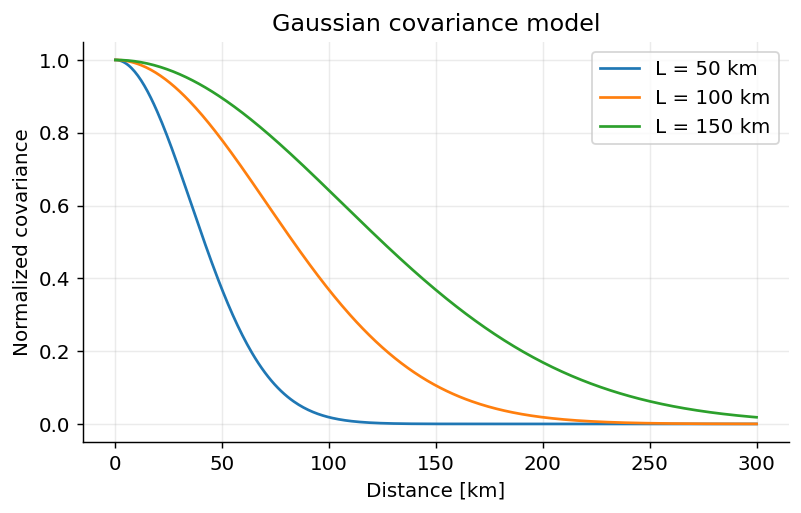

In [35]:
def gaussian_covariance(d_km, signal_var, L_km):
    return signal_var * np.exp(-(np.asarray(d_km) / L_km) ** 2)


dist_demo = np.linspace(0, 300, 400)

fig, ax = plt.subplots(figsize=(7, 4))
for L in [50, 100, 150]:
    ax.plot(dist_demo, gaussian_covariance(dist_demo, 1.0, L), label=f"L = {L} km")
ax.set_title("Gaussian covariance model")
ax.set_xlabel("Distance [km]")
ax.set_ylabel("Normalized covariance")
ax.legend()
plt.show()

## 6. Didactic 5-point example (step by step)

Before applying OI to real Sentinel-6 data, it helps to see every piece of the calculation on a tiny synthetic example.

We will use **five observations** and estimate the field at **one target grid point**.

This example is deliberately simple so that you can inspect:

- the distances
- the covariance matrix
- the noise matrix
- the OI weights
- the final estimate
- the posterior uncertainty

### Physical intuition to keep in mind

- closer points should usually matter more than distant points
- if the decorrelation scale $L$ is large, distant points remain influential
- if the observation noise is large, the estimate trusts the data less
- if nearby observations strongly disagree, OI balances them according to covariance and noise

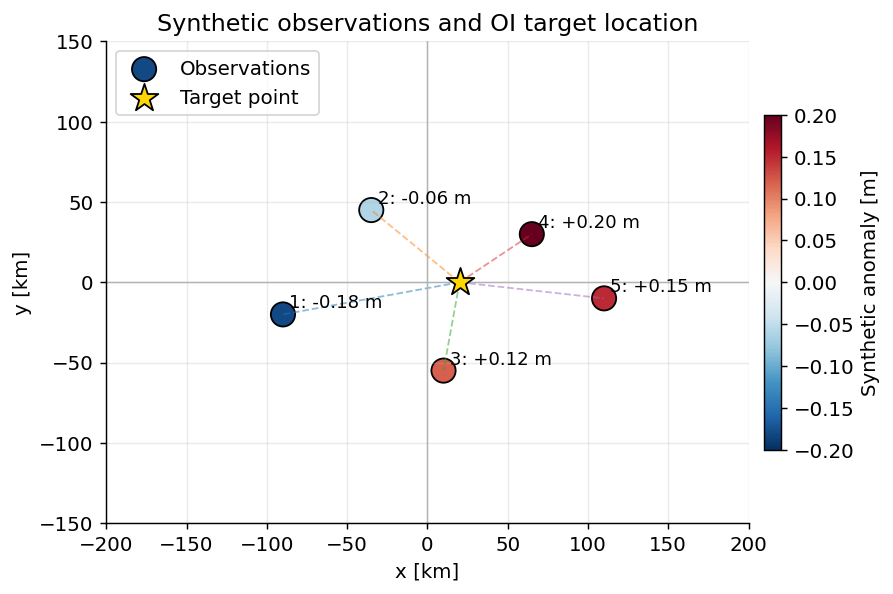

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Synthetic observation geometry in km on a local x-y plane
obs_xy = np.array([
    [-90.0, -20.0],
    [-35.0,  45.0],
    [ 10.0, -55.0],
    [ 65.0,  30.0],
    [110.0, -10.0],
])

obs_val = np.array([-0.18, -0.06, 0.12, 0.20, 0.15])  # synthetic anomaly [m]
target_xy = np.array([20.0, 0.0])

fig, ax = plt.subplots(figsize=(7, 5.5))

sc = ax.scatter(
    obs_xy[:, 0],
    obs_xy[:, 1],
    c=obs_val,
    s=180,
    cmap="RdBu_r",
    edgecolor="k",
    vmin=-0.2,
    vmax=0.2,
    label="Observations",
)

ax.scatter(
    target_xy[0],
    target_xy[1],
    marker="*",
    s=260,
    c="gold",
    edgecolor="k",
    linewidth=1.0,
    label="Target point",
    zorder=5,
)

for i, ((x, y), val) in enumerate(zip(obs_xy, obs_val), start=1):
    ax.text(x + 4, y + 4, f"{i}: {val:+.2f} m", fontsize=10)

# Dashed lines from target to each observation
for x, y in obs_xy:
    ax.plot([target_xy[0], x], [target_xy[1], y], "--", linewidth=1, alpha=0.5)

ax.axhline(0, linewidth=0.8, color="0.7")
ax.axvline(0, linewidth=0.8, color="0.7")

ax.set_xlabel("x [km]")
ax.set_ylabel("y [km]")
ax.set_title("Synthetic observations and OI target location")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="upper left")
ax.set_xlim(-200,200)
ax.set_ylim(-150,150)
cbar = plt.colorbar(sc, ax=ax, pad=0.02,shrink=0.5)
cbar.set_label("Synthetic anomaly [m]")

plt.tight_layout()
plt.show()

In [37]:
signal_std_m = 0.15
signal_var = signal_std_m ** 2
L_demo_km = 100.0
noise_std_m = 0.03

d_oo = cdist(obs_xy, obs_xy)
d_xo = np.sqrt(((obs_xy - target_xy[None, :]) ** 2).sum(axis=1))

Coo_demo = gaussian_covariance(d_oo, signal_var, L_demo_km)
R_demo = (noise_std_m ** 2) * np.eye(len(obs_xy))
Cxo_demo = gaussian_covariance(d_xo, signal_var, L_demo_km)

alpha_demo = np.linalg.solve(Coo_demo + R_demo, Cxo_demo)
xhat_demo = float(alpha_demo @ obs_val)
post_var_demo = float(signal_var - Cxo_demo @ alpha_demo)
post_std_demo = np.sqrt(max(post_var_demo, 0.0))

labels = [f"O{i}" for i in range(1, 6)]

print("Distances between observations [km]:")
display(pd.DataFrame(d_oo, index=labels, columns=labels).round(1))

print("Observation covariance Coo [m^2]:")
display(pd.DataFrame(Coo_demo, index=labels, columns=labels).round(4))

print("Noise covariance R [m^2]:")
display(pd.DataFrame(R_demo, index=labels, columns=labels).round(4))

print("Target-to-observation covariance Cxo [m^2]:")
display(pd.DataFrame({"Cxo": Cxo_demo}, index=labels).round(4))

print("OI weights (alpha = (Coo + R)^-1 Cxo):")
display(pd.DataFrame({"weight": alpha_demo}, index=labels).round(4))

print(f"Estimated value at target = {xhat_demo:.3f} m")
print(f"Posterior standard deviation = {post_std_demo:.3f} m")

Distances between observations [km]:


,O1,O2,O3,O4,O5
O1,0.0,85.1,105.9,162.9,200.2
O2,85.1,0.0,109.7,101.1,155.1
O3,105.9,109.7,0.0,101.2,109.7
O4,162.9,101.1,101.2,0.0,60.2
O5,200.2,155.1,109.7,60.2,0.0


Observation covariance Coo [m^2]:


,O1,O2,O3,O4,O5
O1,0.0225,0.0109,0.0073,0.0016,0.0004
O2,0.0109,0.0225,0.0068,0.0081,0.0020
O3,0.0073,0.0068,0.0225,0.0081,0.0068
O4,0.0016,0.0081,0.0081,0.0225,0.0157
O5,0.0004,0.0020,0.0068,0.0157,0.0225


Noise covariance R [m^2]:


...

Target-to-observation covariance Cxo [m^2]:


,Cxo
O1,0.0064
O2,0.0136
O3,0.0165
O4,0.0168
O5,0.0099


OI weights (alpha = (Coo + R)^-1 Cxo):


,weight
O1,-0.0449
O2,0.2943
O3,0.4808
O4,0.5056
O5,-0.0785


Estimated value at target = 0.137 m
Posterior standard deviation = 0.056 m


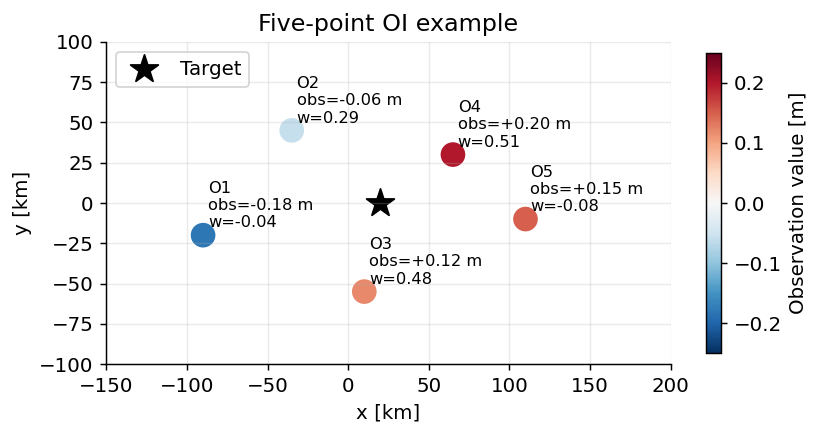

In [38]:
fig, ax = plt.subplots(figsize=(7, 6))

sc = ax.scatter(
    obs_xy[:, 0], obs_xy[:, 1],
    c=obs_val,
    s=160,
    cmap=CMAP_ANOM,
    vmin=-0.25, vmax=0.25,
)
ax.scatter(target_xy[0], target_xy[1], marker="*", s=260, color="k", label="Target")

for i, ((x, y), val, w) in enumerate(zip(obs_xy, obs_val, alpha_demo), start=1):
    ax.text(
        x + 3, y + 3,
        f"O{i}\nobs={val:+.2f} m\nw={w:.2f}",
        fontsize=9,
        ha="left", va="bottom",
    )

ax.set_title("Five-point OI example")
ax.set_xlabel("x [km]")
ax.set_ylabel("y [km]")
ax.set_aspect("equal")
ax.set_xlim(-150,200)
ax.set_ylim(-100,100)
ax.legend(loc="upper left")
fig.colorbar(sc, ax=ax, label="Observation value [m]",shrink=0.5)
plt.show()

### Reading the 5-point example

The matrix $C_{oo}$ says how similar each observation is expected to be to every other observation under our covariance model.

- points that are close together have larger covariance
- distant points have smaller covariance
- the diagonal contains the signal variance $\sigma_s^2$

The matrix $R$ adds observation noise.  
That prevents the analysis from overfitting noisy data and improves matrix conditioning.

The vector $C_{xo}$ measures how strongly the target point should covary with each observation.

Finally, the OI weights are **not** chosen by hand.  
They are determined by the covariance and noise model through linear algebra.

This is the key conceptual jump from deterministic smoothing to statistical estimation.

## 7. Full OI application to Sentinel-6A data

For the real case study we apply a simple but instructive local OI.

### Practical step: superobbing / spatial thinning

Along-track altimetry is very dense **along track** compared with **across-track** spacing.  
If we feed all raw observations into OI, nearby points on the same track can dominate the covariance system.

Operational mapping systems often reduce this redundancy before OI.  
Here we use a simple **spatial superob** step:

- group raw observations into small spatial bins
- average observations within each bin
- treat the bin average as one representative observation

This is not mandatory, but it makes the example cleaner and computationally cheaper.

In [39]:
def make_superobs(obs_df, bbox, ddeg=0.15):
    west, south, east, north = bbox
    df = obs_df.copy()

    df["i"] = np.floor((df["lon"] - west) / ddeg).astype(int)
    df["j"] = np.floor((df["lat"] - south) / ddeg).astype(int)

    grouped = (
        df.groupby(["i", "j"], as_index=False)
          .agg(
              lon=("lon", "mean"),
              lat=("lat", "mean"),
              ssha_m=("ssha_m", "mean"),
              n=("ssha_m", "size"),
              time=("time", "mean"),
          )
          .sort_values("time")
          .reset_index(drop=True)
    )
    return grouped


superobs = make_superobs(obs, CASE["bbox"], ddeg=SUPEROB_DDEG)

display(pd.DataFrame({
    "raw_observations": [len(obs)],
    "superobservations": [len(superobs)],
    "mean_raw_points_per_superob": [superobs["n"].mean()],
    "median_raw_points_per_superob": [superobs["n"].median()],
}))
display(superobs.head())

,raw_observations,superobservations,mean_raw_points_per_superob,median_raw_points_per_superob
0,3336,1373,2.429716,2.0


,i,j,lon,lat,ssha_m,n,time
0,4,15,-75.376371,34.368461,0.1206,2,2024-03-01 00:38:19.500
1,22,43,-72.699452,38.591548,0.0194,1,2024-03-01 00:39:51.000
2,29,53,-71.646664,40.093097,0.0332,1,2024-03-01 00:40:24.000
3,41,69,-69.842507,42.476540,0.1276,1,2024-03-01 00:41:17.000
4,41,71,-69.700206,42.654891,0.1441,1,2024-03-01 00:41:21.000


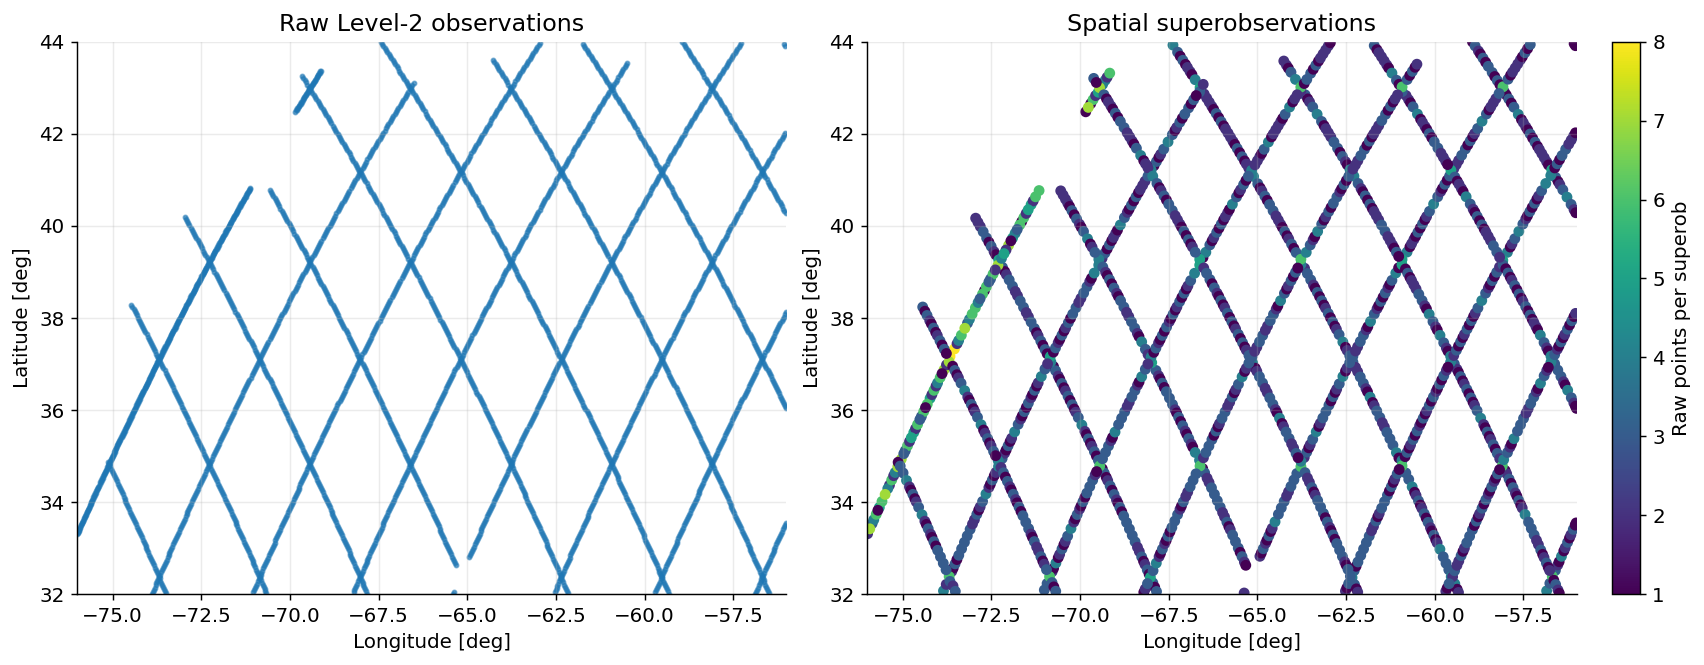

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

axes[0].scatter(obs["lon"], obs["lat"], s=5, alpha=0.6)
axes[0].set_title("Raw Level-2 observations")
axes[0].set_xlabel("Longitude [deg]")
axes[0].set_ylabel("Latitude [deg]")
axes[0].set_xlim(west, east)
axes[0].set_ylim(south, north)

sc = axes[1].scatter(
    superobs["lon"], superobs["lat"],
    c=superobs["n"],
    s=25,
    cmap="viridis",
)
axes[1].set_title("Spatial superobservations")
axes[1].set_xlabel("Longitude [deg]")
axes[1].set_ylabel("Latitude [deg]")
axes[1].set_xlim(west, east)
axes[1].set_ylim(south, north)
fig.colorbar(sc, ax=axes[1], label="Raw points per superob")

plt.show()

In [41]:
def optimal_interpolation_local(
    obs_df,
    lon_centers,
    lat_centers,
    L_km=120.0,
    noise_std_m=0.03,
    signal_std_m=None,
    influence_km=None,
    min_neighbors=3,
    max_neighbors=20,
    nugget=1e-10,
):
    """
    Local isotropic Gaussian OI on a regular grid.

    Parameters
    ----------
    obs_df : DataFrame with columns lon, lat, ssha_m
    lon_centers, lat_centers : 1D arrays of target-grid centers
    L_km : decorrelation scale
    noise_std_m : assumed observation error std
    signal_std_m : signal std; if None, estimate from observations
    influence_km : search radius for local neighborhoods
    min_neighbors, max_neighbors : neighborhood controls
    nugget : tiny diagonal term for numerical stability
    """
    if signal_std_m is None:
        signal_std_m = float(np.nanstd(obs_df["ssha_m"].values))

    signal_var = signal_std_m ** 2

    if influence_km is None:
        influence_km = 3.0 * L_km

    x_obs, y_obs, lon0, lat0 = lonlat_to_xy_km(
        obs_df["lon"].values,
        obs_df["lat"].values,
    )
    obs_val = obs_df["ssha_m"].values

    glon2d, glat2d = np.meshgrid(lon_centers, lat_centers)
    xg, yg, _, _ = lonlat_to_xy_km(glon2d, glat2d, lon0=lon0, lat0=lat0)

    tree = cKDTree(np.c_[x_obs, y_obs])

    analysis = np.full(xg.shape, np.nan)
    error_std = np.full(xg.shape, np.nan)
    neighbor_count = np.zeros(xg.shape, dtype=int)

    for i, pt in enumerate(np.c_[xg.ravel(), yg.ravel()]):
        idx = tree.query_ball_point(pt, r=influence_km)

        if len(idx) < min_neighbors:
            continue

        idx = np.asarray(idx, dtype=int)

        if len(idx) > max_neighbors:
            d = np.hypot(x_obs[idx] - pt[0], y_obs[idx] - pt[1])
            idx = idx[np.argsort(d)[:max_neighbors]]

        xo = x_obs[idx]
        yo = y_obs[idx]
        vals = obs_val[idx]

        local_xy = np.c_[xo, yo]
        d_oo = cdist(local_xy, local_xy)
        d_xo = np.sqrt((xo - pt[0]) ** 2 + (yo - pt[1]) ** 2)

        Coo = gaussian_covariance(d_oo, signal_var, L_km)
        Cxo = gaussian_covariance(d_xo, signal_var, L_km)
        A = Coo + (noise_std_m ** 2 + nugget) * np.eye(len(idx))

        alpha = np.linalg.solve(A, Cxo)
        analysis.ravel()[i] = float(alpha @ vals)

        post_var = signal_var - Cxo @ alpha
        error_std.ravel()[i] = np.sqrt(max(float(post_var), 0.0))
        neighbor_count.ravel()[i] = len(idx)

    coords = {"lat": lat_centers, "lon": lon_centers}
    return (
        xr.DataArray(analysis, coords=coords, dims=("lat", "lon"), name="oi_ssha"),
        xr.DataArray(error_std, coords=coords, dims=("lat", "lon"), name="oi_error_std"),
        xr.DataArray(neighbor_count, coords=coords, dims=("lat", "lon"), name="oi_n"),
    )

In [42]:
signal_std_est = float(np.nanstd(superobs["ssha_m"].values))

oi_grid, oi_error_std, oi_neighbors = optimal_interpolation_local(
    superobs,
    lon_centers,
    lat_centers,
    L_km=OI_DECORR_KM,
    noise_std_m=OI_NOISE_STD_M,
    signal_std_m=signal_std_est,
    influence_km=OI_INFLUENCE_KM,
    min_neighbors=OI_MIN_NEIGHBORS,
    max_neighbors=OI_MAX_NEIGHBORS,
)

display(pd.DataFrame({
    "estimated_signal_std_m": [signal_std_est],
    "OI_decorrelation_scale_km": [OI_DECORR_KM],
    "OI_noise_std_m": [OI_NOISE_STD_M],
    "OI_influence_radius_km": [OI_INFLUENCE_KM],
}))

,estimated_signal_std_m,OI_decorrelation_scale_km,OI_noise_std_m,OI_influence_radius_km
0,0.178663,120.0,0.03,360.0


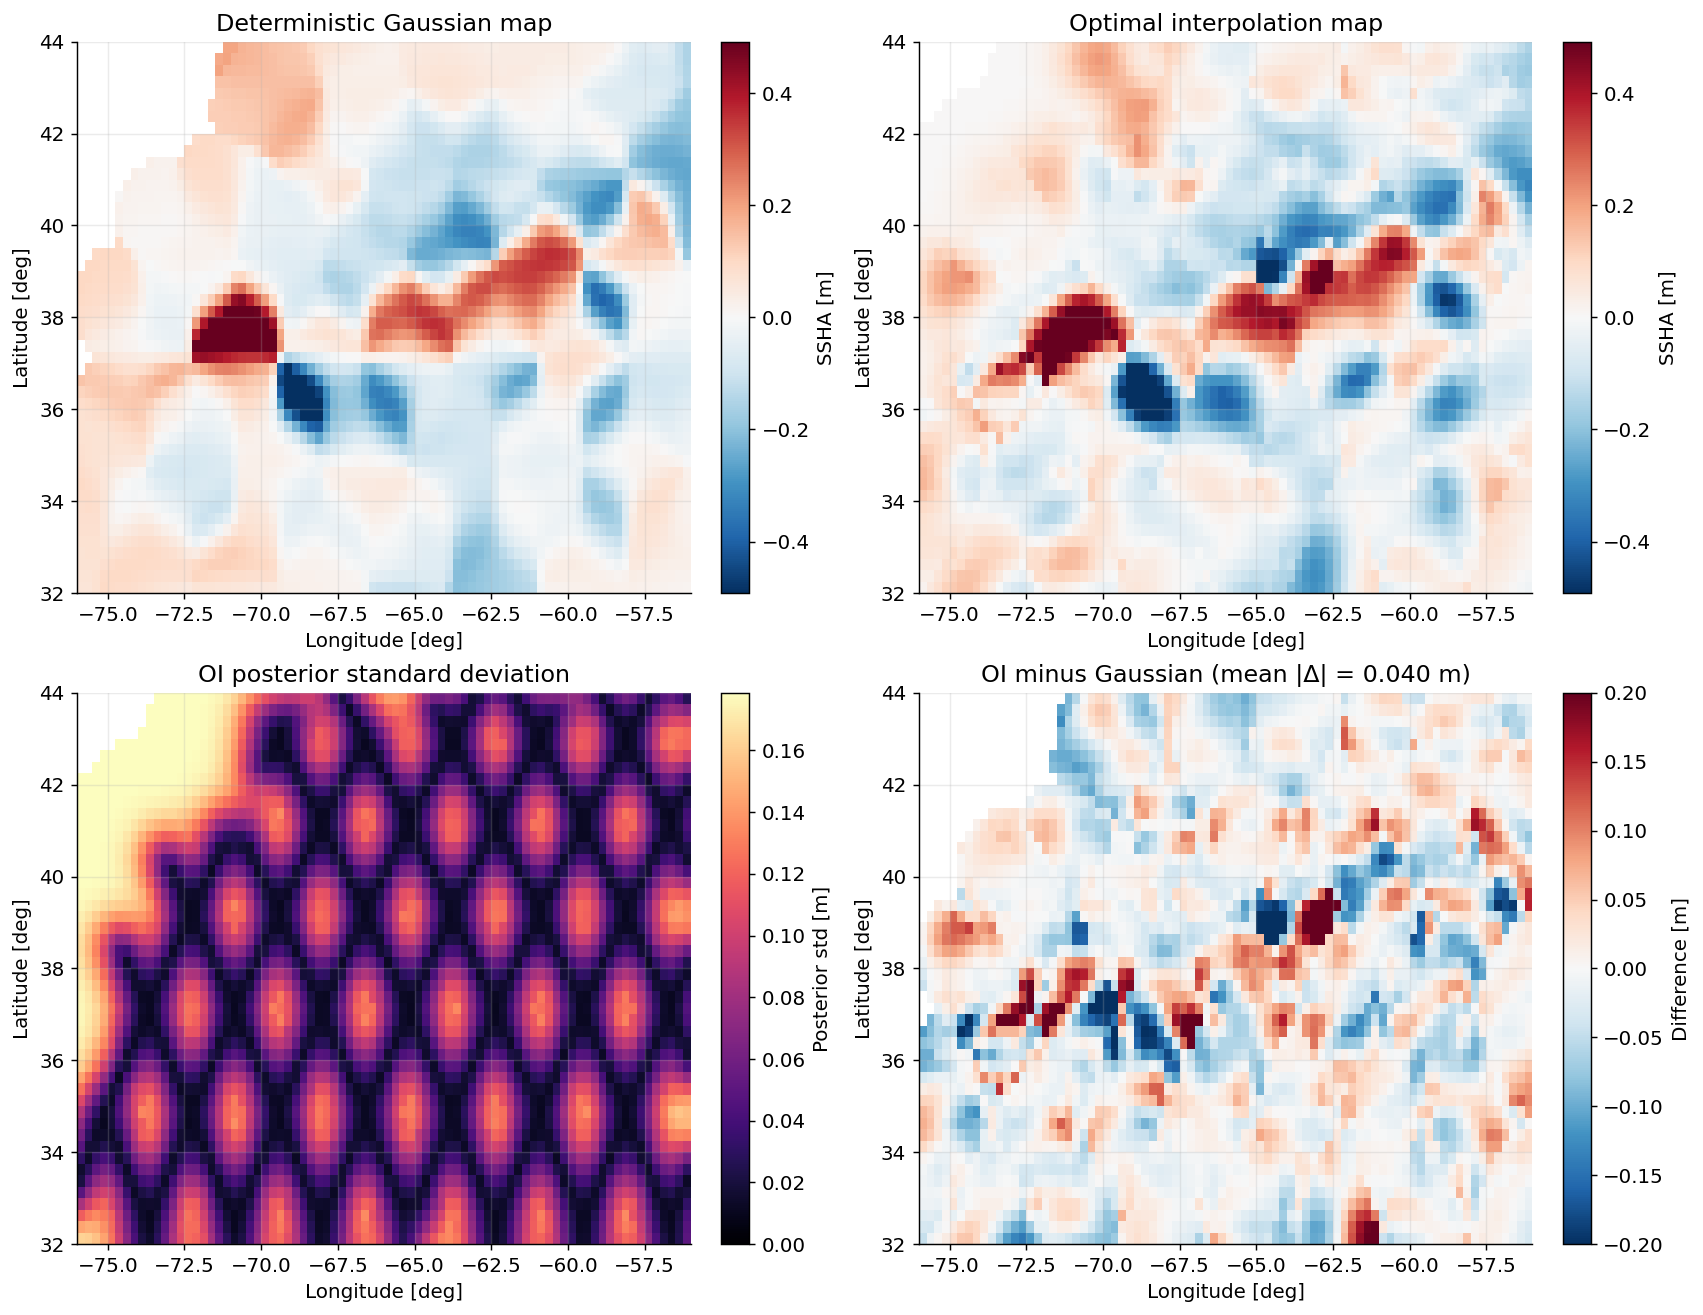

In [43]:
oi_minus_gauss = oi_grid - gauss_grid
mean_abs_diff = float(np.nanmean(np.abs(oi_minus_gauss.values)))

fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)

im = plot_lonlat_field(
    axes[0, 0], gauss_grid,
    "Deterministic Gaussian map",
    vmin=-anom_limit, vmax=anom_limit,
)
fig.colorbar(im, ax=axes[0, 0], label="SSHA [m]")

im = plot_lonlat_field(
    axes[0, 1], oi_grid,
    "Optimal interpolation map",
    vmin=-anom_limit, vmax=anom_limit,
)
fig.colorbar(im, ax=axes[0, 1], label="SSHA [m]")

im = plot_lonlat_field(
    axes[1, 0], oi_error_std,
    "OI posterior standard deviation",
    cmap="magma",
    vmin=0,
    vmax=float(np.nanpercentile(oi_error_std.values, 99)),
)
fig.colorbar(im, ax=axes[1, 0], label="Posterior std [m]")

im = plot_lonlat_field(
    axes[1, 1], oi_minus_gauss,
    f"OI minus Gaussian (mean |Δ| = {mean_abs_diff:.3f} m)",
    vmin=-0.20, vmax=0.20,
)
fig.colorbar(im, ax=axes[1, 1], label="Difference [m]")

plt.show()

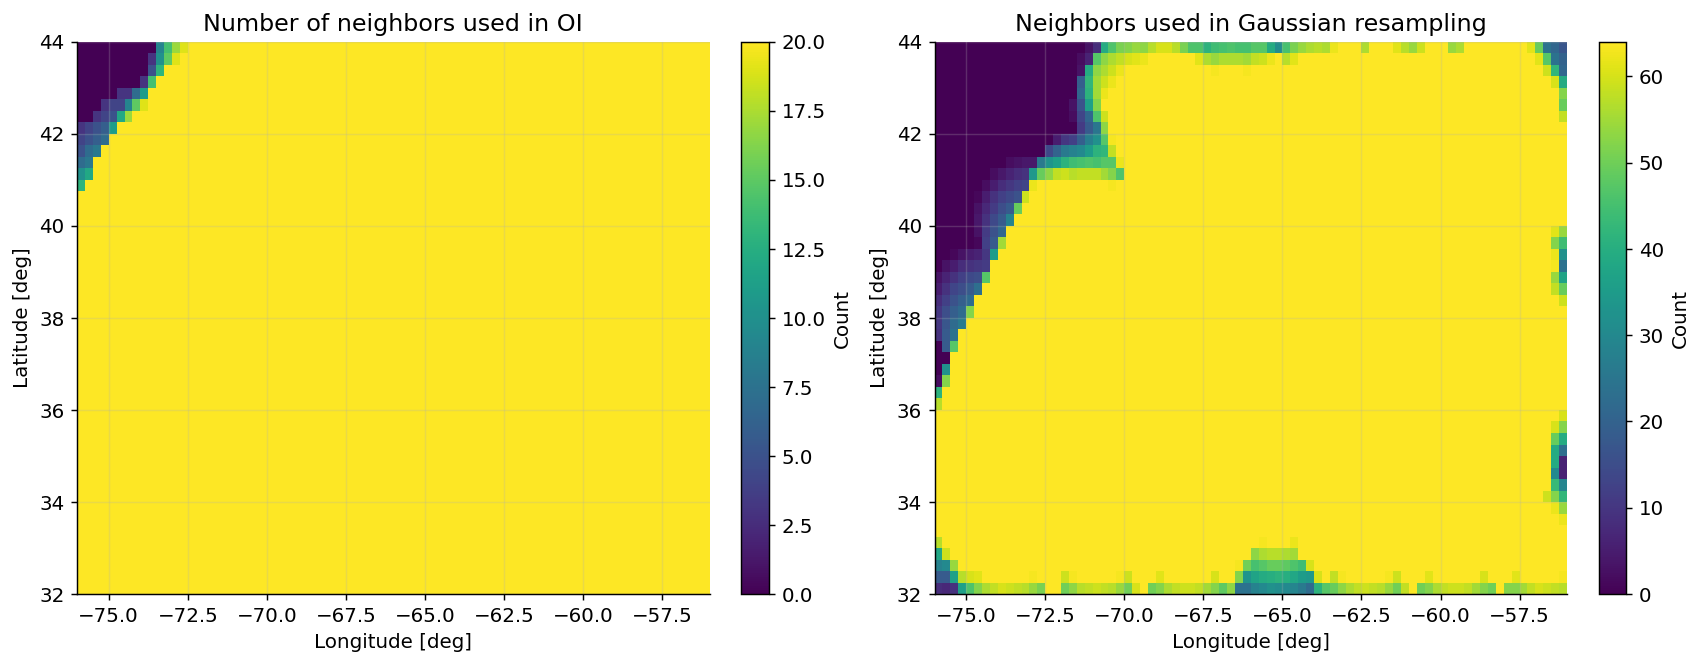

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

im = plot_lonlat_field(
    axes[0], oi_neighbors,
    "Number of neighbors used in OI",
    cmap="viridis",
    vmin=0,
    vmax=float(np.nanpercentile(oi_neighbors.values, 99)),
)
fig.colorbar(im, ax=axes[0], label="Count")

im = plot_lonlat_field(
    axes[1], gauss_count,
    "Neighbors used in Gaussian resampling",
    cmap="viridis",
    vmin=0,
    vmax=float(np.nanpercentile(gauss_count.values, 99)),
)
fig.colorbar(im, ax=axes[1], label="Count")

plt.show()

### Comparison: deterministic gridding versus OI

The two methods can produce superficially similar maps, but they answer slightly different questions.

#### Deterministic Gaussian resampling
- smooths nearby observations onto the grid
- useful as a fast, intuitive Level-4 estimate
- no formal statistical error estimate

#### Optimal interpolation
- uses an explicit covariance model and noise model
- downweights redundant or noisy observations in a principled way
- returns a **posterior uncertainty** map
- makes the smoothing scale interpretable through the decorrelation scale $L$

So OI is not just a prettier smoother.  
It is a model-based **estimator**.

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

Opened file: data_nasa_ssh_ref_simple_grid_v1/NASA-SSH_alt_ref_simple_grid_v1_20240226.nc
<xarray.Dataset> Size: 6MB
Dimensions:            (latitude: 360, longitude: 720, basins: 293)
Coordinates:
  * latitude           (latitude) float32 1kB -89.75 -89.25 ... 89.25 89.75
  * longitude          (longitude) float32 3kB 0.25 0.75 1.25 ... 359.2 359.8
Dimensions without coordinates: basins
Data variables:
    ssha               (latitude, longitude) float64 2MB ...
    basin_flag         (latitude, longitude) float64 2MB ...
    counts             (latitude, longitude) float64 2MB ...
    time               datetime64[ns] 8B ...
    basin_names_table  (basins) <U33 39kB ...
Attributes: (12/37)
    Conventions:               CF-1.7
    title:                     NASA-SSH Simple Gridded Sea Surface Height fro...
    summary:                   This data set contains satellite based measure...
    acknowledgement:           This data is provided by NASAs PO.DAAC.
    license:                

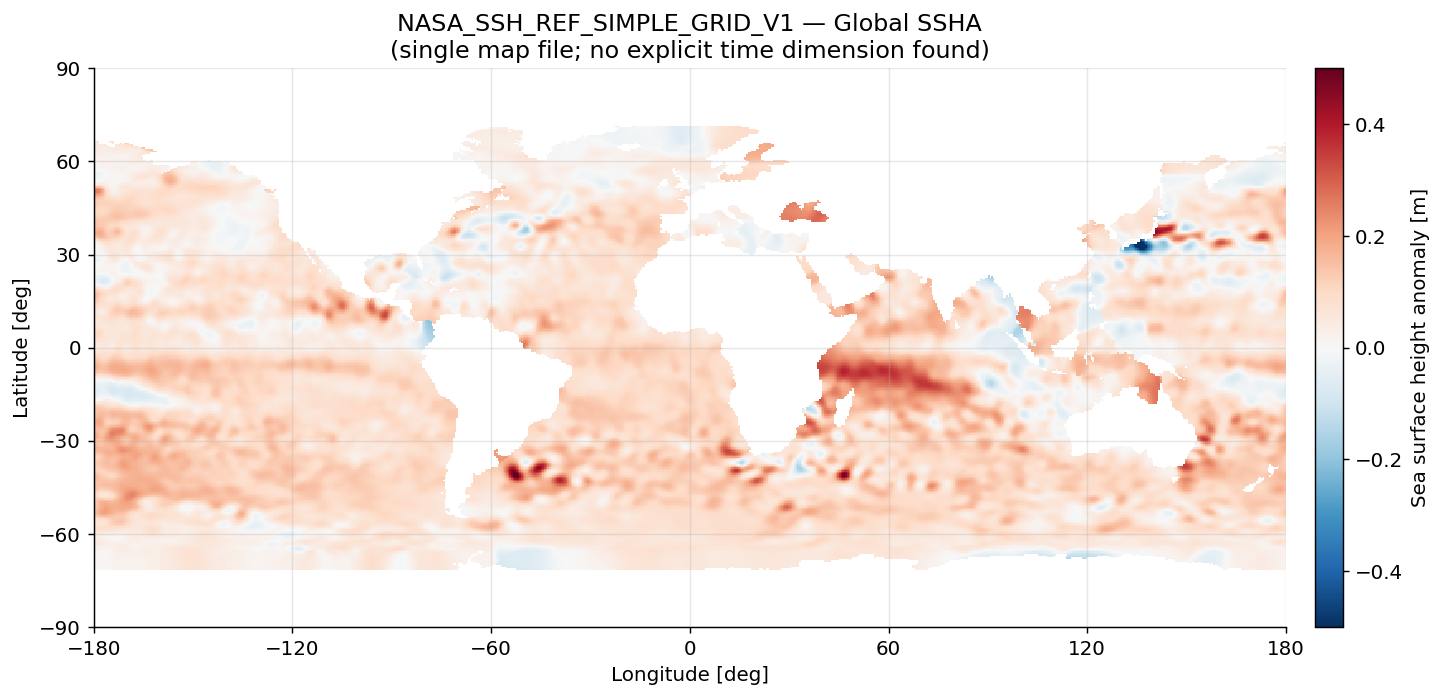

In [45]:
## An example from the NASA official product
# NASA_SSH_REF_SIMPLE_GRID_V1
# Plot one global SSHA map nearest to 2025-01-01

import earthaccess
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# -----------------------------
# 1) Authenticate and search
# -----------------------------
auth = earthaccess.login()

results = earthaccess.search_data(
    short_name="NASA_SSH_REF_SIMPLE_GRID_V1",
    temporal=("2024-03-01", "2024-03-11"),  # wide enough to catch the weekly product nearest 2025-01-01
)

if len(results) == 0:
    raise RuntimeError("No granules found for NASA_SSH_REF_SIMPLE_GRID_V1 in requested window.")

# Download/open the first matching granule
files = earthaccess.download(results[:1], local_path="data_nasa_ssh_ref_simple_grid_v1")
fn = files[0]
print("Opened file:", fn)

# -----------------------------
# 2) Load with xarray
# -----------------------------
ds = xr.open_dataset(fn)

print(ds)
print("\nVariables:", list(ds.data_vars))
print("Coordinates:", list(ds.coords))

# -----------------------------
# 3) Select the time nearest to 2025-01-01
# -----------------------------
target_time = np.datetime64("2024-03-05")

# Decode CF times if needed
if not np.issubdtype(ds["time"].dtype, np.datetime64):
    ds = xr.decode_cf(ds)

# Select nearest available map time
if "time" in ds.dims or "time" in ds.coords:
    ds_sel = ds.sel(time=target_time, method="nearest")
    actual_time = np.asarray(ds_sel["time"].values).item()
else:
    ds_sel = ds
    actual_time = None

print("Selected time:", actual_time)

# -----------------------------
# 4) Get variables
# -----------------------------
# PO.DAAC variable names listed for this collection:
# latitude, longitude, ssha, time, counts
lat = ds_sel["latitude"]
lon = ds_sel["longitude"]
ssha = ds_sel["ssha"]

# Convert longitudes from 0..360 to -180..180 for prettier global plotting
lon180 = ((lon + 180) % 360) - 180
sort_idx = np.argsort(lon180.values)

lon_plot = lon180.values[sort_idx]
ssha_plot = ssha.values[..., sort_idx]

# Mask fill values / absurd values
ssha_plot = np.where(np.abs(ssha_plot) > 1e10, np.nan, ssha_plot)

# -----------------------------
# 5) Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 5.5))

pcm = ax.pcolormesh(
    lon_plot,
    lat.values,
    ssha_plot,
    shading="auto",
    cmap="RdBu_r",
    vmin=-0.5,
    vmax=0.5,
)

cb = plt.colorbar(pcm, ax=ax, pad=0.02)
cb.set_label("Sea surface height anomaly [m]")

title = "NASA_SSH_REF_SIMPLE_GRID_V1 — Global SSHA"
if actual_time is not None:
    # Convert to nice printable date
    actual_time_str = np.datetime_as_string(np.datetime64(actual_time), unit="D")
    title += f"\nNearest available map to 2025-01-01: {actual_time_str}"
else:
    title += "\n(single map file; no explicit time dimension found)"

ax.set_title(title)
ax.set_xlabel("Longitude [deg]")
ax.set_ylabel("Latitude [deg]")
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xticks(np.arange(-180, 181, 60))
ax.set_yticks(np.arange(-90, 91, 30))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Scientific interpretation

### 8.1 What scales are resolved?

A useful rule of thumb is that a gridded product cannot reliably resolve scales much smaller than:

- the **across-track spacing**
- the chosen **mapping length scale**
- the time-evolution timescale over the averaging window

For a single nadir altimeter, the across-track gaps are large relative to mesoscale eddies.  
That is why the choice of $L$ matters so much.

If $L$ is:

- **too small**: the map becomes patchy and stripe-like
- **too large**: the map becomes too smooth and loses fronts / eddy gradients

### 8.2 Mesoscale context

Midlatitude mesoscale variability is often on the order of **100 km** (very loosely, depending on region and season).  
That is why decorrelation scales of roughly **75–150 km** are common teaching values for regional examples like this one.

### 8.3 Nadir altimetry versus SWOT

A nadir altimeter samples one dimension well: **along track**.  
It is much weaker across track, so Level-4 maps rely heavily on interpolation assumptions.

SWOT changes the geometry by providing a **2-D swath**, which greatly improves sampling of fronts and short-wavelength variability.  
That does **not** remove all mapping problems, but it changes them fundamentally.

### 8.4 Relation to operational products

Operational multi-mission systems such as **DUACS** improve mapping by combining:
- multiple satellites
- longer time windows (or full space-time covariance models)
- tuned correlation scales
- careful error characterization

That is one reason operational Level-4 products usually outperform a single-satellite classroom example like the one in this notebook.

In [46]:
# A rough sampling sanity check using the equatorial cross-track spacing
# quoted for Sentinel-6A. This is only a back-of-the-envelope estimate.
lat_mid = 0.5 * (south + north)
approx_spacing_km = 315.0 * np.cos(np.deg2rad(lat_mid))

print(f"Case-study midlatitude: {lat_mid:.1f}°N")
print(f"Approximate cross-track spacing near this latitude: {approx_spacing_km:.0f} km")
print(f"Chosen OI decorrelation scale: {OI_DECORR_KM:.0f} km")

Case-study midlatitude: 38.0°N
Approximate cross-track spacing near this latitude: 248 km
Chosen OI decorrelation scale: 120 km


## 9. Optional extensions

### Extension A — make OI time dependent

Replace the purely spatial covariance by a space-time covariance such as
$$
C(\Delta r, \Delta t) =
\sigma_s^2
\exp\!\left[-\left(\frac{\Delta r}{L}\right)^2\right]
\exp\!\left[-\left(\frac{\Delta t}{T}\right)^2\right]
$$
where $T$ is a temporal decorrelation scale.

That is closer to operational objective mapping.

### Extension B — merge multiple altimeters

Repeat the workflow with multiple nadir missions and compare the result with the single-satellite map.  
This is the core idea behind products such as DUACS.

### Extension D — map ADT instead of SSHA

If `mean_dynamic_topography` is available in the Level-2 granule, a simple pedagogical extension is

$$
\mathrm{ADT} = \mathrm{SSHA} + \mathrm{MDT}
$$

after checking the variable conventions in the product documentation.

## 10. Exercises

### Exercise 1 — deterministic mapping sensitivity
Change:
- the grid spacing
- the Gaussian radius of influence
- the Gaussian sigma

Questions:
1. When do holes begin to appear?
2. When does the map become overly smooth?
3. How different is nearest neighbor from Gaussian weighting?

### Exercise 2 — OI length-scale tuning
Run the full OI for

- $L = 75$ km
- $L = 120$ km
- $L = 180$ km

Then compare:
- the mapped SSHA
- the OI posterior standard deviation
- the difference from deterministic Gaussian resampling

### Exercise 3 — noise sensitivity
Change the assumed noise level from 1 cm to 5 cm.

Questions:
1. How do the OI weights change?
2. What happens to the posterior uncertainty?
3. Does the mapped field become smoother or noisier?

### Challenge problem
Design a small experiment to choose $L$ objectively.

Ideas:
- compare your map to withheld observations (cross-validation)
- minimize RMS error at withheld points
- test whether one $L$ works better inside the energetic Gulf Stream than outside it

## 11. Key takeaways

1. **Level-2** altimetry is an irregular along-track measurement set.
2. **Level-4** products require a mapping choice, not just a plotting choice.
3. **Deterministic gridding** is simple and fast, but it does not provide a formal uncertainty.
4. **Optimal interpolation** combines physics/statistics intuition with linear algebra:
   - covariance sets how information spreads in space
   - noise controls how strongly observations are trusted
   - posterior variance gives a mapping error estimate
5. For single-satellite nadir altimetry, the grid is often smoother than the ocean really is.
   That is a property of the observing system, not just the plotting method.

## 12. References and further reading

### Data products and documentation
- NASA PO.DAAC / Earthdata: **Sentinel-6A MF Jason-CS P4 Altimeter, L2 Altimeter Low Resolution, NTC, OST, G01**
- NASA PO.DAAC / Earthdata: official Sentinel-6A **Level-3** low-resolution ocean surface topography collections
- PO.DAAC data cookbook examples for **Sentinel-6A altimetry** with `earthaccess`
- Sentinel-6/Jason-CS variable catalog pages for `ssha`, `surface_classification_flag`, and related QC variables

### Mapping / gridding references
- Bretherton, F. P., Davis, R. E., & Fandry, C. B. (1976). *A technique for objective analysis and design of oceanographic experiments applied to MODE-73*. Deep-Sea Research.
- Le Traon, P.-Y., Nadal, F., & Ducet, N. (1998). *An improved mapping method of multisatellite altimeter data*. Journal of Atmospheric and Oceanic Technology.
- Ducet, N., Le Traon, P.-Y., & Reverdin, G. (2000). *Global high-resolution mapping of ocean circulation from TOPEX/Poseidon and ERS-1 and -2*. Journal of Geophysical Research.
- Pujol, M.-I., et al. (2016). *DUACS DT2014: the new multi-mission altimeter data set reprocessed over 20 years*. Ocean Science.
- Ballarotta, M., et al. (2019). *On the resolutions of ocean altimetry maps*. Ocean Science.

### Mission / science context
- Morrow, R., et al. (2019). *Global observations of fine-scale ocean surface topography with the Surface Water and Ocean Topography (SWOT) mission*. Frontiers in Marine Science.
- Fu, L.-L., et al. (2024 and related SWOT mission papers). Wide-swath altimetry and submesoscale/mesoscale observing capability.

> Can you compare your OI map with an operational multi-mission product and discuss the difference between **sampling error** and **mapping error**?